# Comments on Martin Wolf on the "European Miracle"

# The Human Economy
<p style="text-align: right;">
    <img src="images/world-population.png"
     alt="J. Bradford DeLong"
     width="300"
     height="300"
     align="right"
     style="float:right; margin: 0 0 10px 10px;" /></p>

### Population

* We have censuses, and guesstimates.

---

### Production *per capita*

#### Necessities, conveniences & luxuries, & cultural goods

* Conceptually the question is easy: what multiple/fraction of average income at time X would make you indifferent between living then and living at the average income at time Y?
* But implementation? Hah!
* Necessities—we have, not nailed, but under controi
* Conveniences & luxuries: much harder, as problems of valuation become absurdly difficult.
* Cultural goods—positive & negative—simply impossible.
* Inequality & domination...

---

### Human technological capability:

* Our ability to manipulate nature and (productively) organize ourselves
* Grows as the pace of growth of production per capita plus half the pace of growth of population
    * Why not plus growth rate of population? Assumes workers not productive
    * Why not just the growth of income per capita? Assumes resources not important

---

### Inequality

* Within societies: a big upward leap around the year -3000
    * Bronze, writing
    * The horse, the wheel, high patriarchy
    * & full-fledged societies of domination
    * Thereafter surprisingly little action, at least not until 1800
    * Then a rise (“Gilded Age”), fall, and rise again (“Second Gilded Age”)
* Between societies: post-1800 inequality explosion

<br style="clear: both;">

---
---

In [1]:
# having done our git-pull: 
#     <https://datahub.berkeley.edu/hub/user-redirect/git-pull?repo=https://github.com/braddelong/working_20251227&urlpath=lab/tree/working_20251227/>
# and having navigated to and opened the right file:
#    venv/working_20251227/2027-03-10-PLANNED-econ-196-week-7-1875-the-hinge.ipynb
# 
# load libraries

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# declare that there will be a dictionary called "pop", fill in population guesstimates 

pop = {} 
pop[2025] = 8250
pop[2000] = 6170 # relying on <http://ourworldindata.org> <https://ourworldindata.org/population-sources>
pop[1975] = 4070
pop[1950] = 2530
pop[1925] = 2000
pop[1900] = 1650
pop[1875] = 1389
pop[1825] = 1100
pop[1775] = 800
pop[1700] = 610
pop[1600] = 500
pop[1500] = 450
pop[1300] = 430
pop[800] = 200
pop[200] = 260
pop[-600] = 150
pop[-1500] = 91
pop[-3000] = 45
pop[-5000] = 19
pop[-8000] = 5 # <https://www.prb.org/articles/how-many-people-have-ever-lived-on-earth/>
pop[-13000] = 4
pop[-23000] = 3
pop[-48000] = 2
pop[-73000] = 0.01 # <https://en.wikipedia.org/wiki/Prehistoric_demography>

# declare that there will be a dataframe object

human_history_df = pd.DataFrame(
                    list(pop.items()),
                    columns=['year', 'population']
                    )

# add in our guesses as to average real income per capita, which is the
# result of how we organize ourselves coöperatively and manipulate nature 
# to produce true necessities and relatively simple conveniences....
#
# "luxuries" and lifespan not accounted for—economists' hunch is that you
# should multiply the power to produce standard commodities by the "size"
# of the space of commodities that you know how to produce, and then multiply
# that by human lifespan before you have anything that might be a true-ish
# measure of "wealth"...
#
# and as for utility? human flourishing? ha!...

human_history_df.loc[human_history_df["year"] == 2025, "income"] = 18000
human_history_df.loc[human_history_df["year"] == 2000, "income"] = 12000
human_history_df.loc[human_history_df["year"] == 1975, "income"] = 8900
human_history_df.loc[human_history_df["year"] == 1950, "income"] = 5800
human_history_df.loc[human_history_df["year"] == 1925, "income"] = 4400
human_history_df.loc[human_history_df["year"] == 1900, "income"] = 3400
human_history_df.loc[human_history_df["year"] == 1875, "income"] = 2200
human_history_df.loc[human_history_df["year"] == 1825, "income"] = 1800
human_history_df.loc[human_history_df["year"] == 1775, "income"] = 1600
human_history_df.loc[human_history_df["year"] == 1700, "income"] = 1525
human_history_df.loc[human_history_df["year"] == 1600, "income"] = 1450
human_history_df.loc[human_history_df["year"] == 1500, "income"] = 1400
human_history_df.loc[human_history_df["year"] == 1300, 'income'] = 1200
human_history_df.loc[human_history_df["year"] == 800, 'income'] = 1100
human_history_df.loc[human_history_df["year"] == 200, 'income'] = 1100
human_history_df.loc[human_history_df["year"] == -600, 'income'] = 1100
human_history_df.loc[human_history_df["year"] == -1500, 'income'] = 1100
human_history_df.loc[human_history_df["year"] == -3000, 'income'] = 1100
human_history_df.loc[human_history_df["year"] == -5000, 'income'] = 1100
human_history_df.loc[human_history_df["year"] == -8000, 'income'] = 1500
human_history_df.loc[human_history_df["year"] == -13000, 'income'] = 1500
human_history_df.loc[human_history_df["year"] == -23000, 'income'] = 1500
human_history_df.loc[human_history_df["year"] == -48000, 'income'] = 1500
human_history_df.loc[human_history_df["year"] == -73000, 'income'] = 1500

# calculating world product

human_history_df["world_product"] = human_history_df["income"] * human_history_df["population"]

# time to look at growth rates

import numpy as np

# 1. Make sure there is no index/column ambiguity and you're sorted by year
human_history_df = human_history_df.reset_index(drop=True)
human_history_df = human_history_df.sort_values("year")

# 2. Year gaps
human_history_df["year_diff"] = human_history_df["year"].diff()

# 3. Annual *log* growth rates
human_history_df["pop_growth"] = (
    np.log(human_history_df["population"])
    - np.log(human_history_df["population"].shift(1))
) / human_history_df["year_diff"]

human_history_df["income_growth"] = (
    np.log(human_history_df["income"])
    - np.log(human_history_df["income"].shift(1))
) / human_history_df["year_diff"]

# calculating "technology"—growth rate equal to income growth plus half of population growth

human_history_df["tech_growth"] = (
    human_history_df["income_growth"] + 0.5 * human_history_df["pop_growth"]
)



#constructing a log-level index for "technology"

human_history_df = human_history_df.sort_values("year").reset_index(drop=True)

human_history_df["ln_tech"] = np.nan

human_history_df.loc[human_history_df["year"] == -73000, "ln_tech"] = 0.0

# build ln_tech forward from the first non-NaN
base_idx = human_history_df["ln_tech"].first_valid_index()
mask_after_base = human_history_df.index > base_idx

human_history_df.loc[mask_after_base, "ln_tech"] = (
    human_history_df.loc[mask_after_base, "tech_growth"]
    * human_history_df.loc[mask_after_base, "year_diff"]
).cumsum()

human_history_df.head()

# exponentiate to get a tech index (base = 1 at year 1875)

human_history_df["tech_index"] = np.exp(human_history_df["ln_tech"])

# find the tech_index value at 1875
base_value_1875 = human_history_df.loc[human_history_df["year"] == 1875, "tech_index"].iloc[0]

# rescale the entire index so that tech_index(1875) = 1
human_history_df["tech_index"] = human_history_df["tech_index"] / base_value_1875

human_history_df.head()

,year,population,income,world_product,year_diff,pop_growth,income_growth,tech_growth,ln_tech,tech_index
0,-73000,0.01,1500.0,15.0,NaN,NaN,NaN,NaN,0.000000,0.001829
1,-48000,2.00,1500.0,3000.0,25000.0,0.000212,0.0,0.000106,2.649159,0.025872
2,-23000,3.00,1500.0,4500.0,25000.0,0.000016,0.0,0.000008,2.851891,0.031687
3,-13000,4.00,1500.0,6000.0,10000.0,0.000029,0.0,0.000014,2.995732,0.036589
4,-8000,5.00,1500.0,7500.0,5000.0,0.000045,0.0,0.000022,3.107304,0.040907


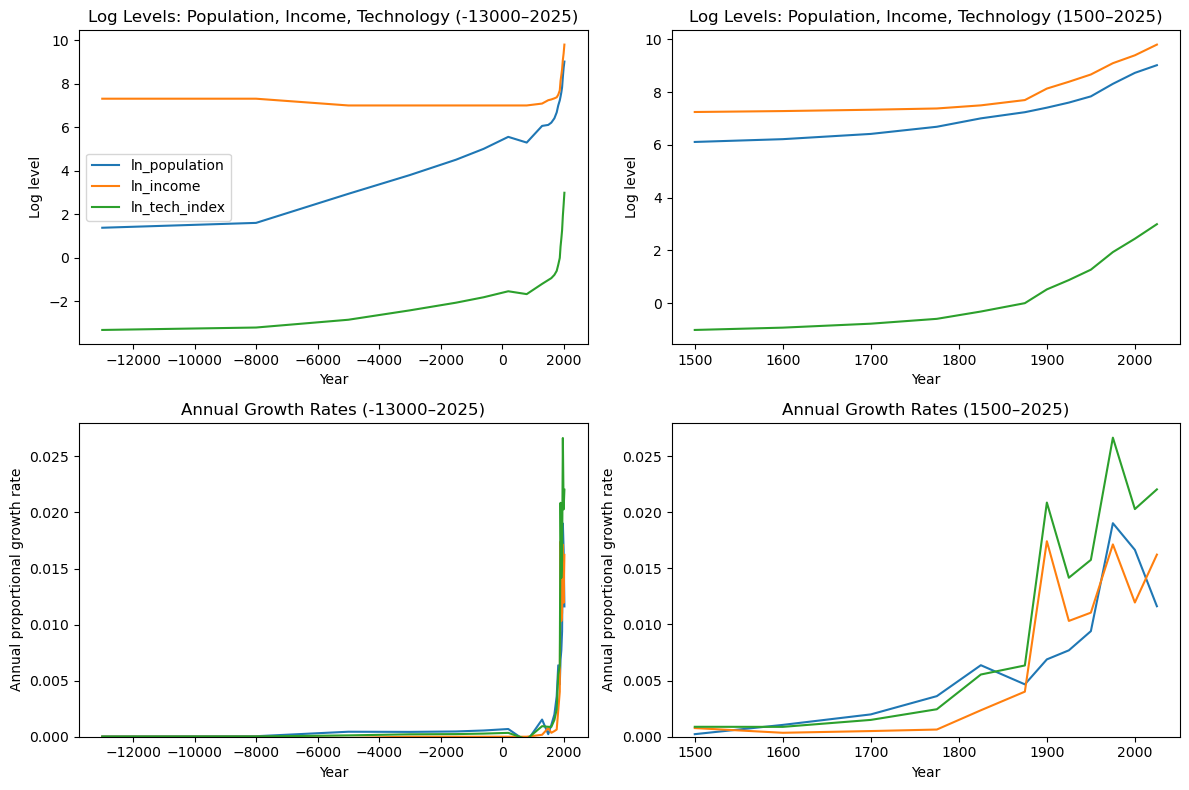

In [2]:
# take a look...


import numpy as np
import matplotlib.pyplot as plt

# Make sure rows are ordered
human_history_df = human_history_df.sort_values("year").reset_index(drop=True)

# Create log-level variables (drop nonpositive values to avoid -inf)
for col in ["population", "income", "tech_index"]:
    human_history_df[f"ln_{col}"] = np.where(
        human_history_df[col] > 0,
        np.log(human_history_df[col]),
        np.nan
    )

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 1. Log levels, -13000 to 2025
mask_long = (human_history_df["year"] >= -13000) & (human_history_df["year"] <= 2025)
human_history_df.loc[mask_long].plot(
    x="year",
    y=["ln_population", "ln_income", "ln_tech_index"],
    kind="line",
    ax=axes[0, 0],
    legend=True
)
axes[0, 0].set_title("Log Levels: Population, Income, Technology (-13000–2025)")
axes[0, 0].set_xlabel("Year")
axes[0, 0].set_ylabel("Log level")

# 2. Log levels, 1500 to 2025
mask_mod = (human_history_df["year"] >= 1500) & (human_history_df["year"] <= 2025)
human_history_df.loc[mask_mod].plot(
    x="year",
    y=["ln_population", "ln_income", "ln_tech_index"],
    kind="line",
    ax=axes[0, 1],
    legend=False
)
axes[0, 1].set_title("Log Levels: Population, Income, Technology (1500–2025)")
axes[0, 1].set_xlabel("Year")
axes[0, 1].set_ylabel("Log level")

# 3. Growth rates, -13000 to 2025
human_history_df.loc[mask_long].plot(
    x="year",
    y=["pop_growth", "income_growth", "tech_growth"],
    kind="line",
    ax=axes[1, 0],
    legend=False
)
axes[1, 0].set_title("Annual Growth Rates (-13000–2025)")
axes[1, 0].set_xlabel("Year")
axes[1, 0].set_ylabel("Annual proportional growth rate")
axes[1, 0].set_ylim(bottom=0)

# 4. Growth rates, 1500 to 2025
human_history_df.loc[mask_mod].plot(
    x="year",
    y=["pop_growth", "income_growth", "tech_growth"],
    kind="line",
    ax=axes[1, 1],
    legend=False
)
axes[1, 1].set_title("Annual Growth Rates (1500–2025)")
axes[1, 1].set_xlabel("Year")
axes[1, 1].set_ylabel("Annual proportional growth rate")
axes[1, 1].set_ylim(bottom=0)

plt.tight_layout()
plt.show()


## Modeling Rates of Technological Progress

It was, I think, in 1985 back when I was still a graduate student that I really became aware of the "two heads are better than one" argument as I watched Paul Romer present a piece of his dissertation—a piece that had already been accepted by and was about to be published in the _Journal of Political Economy_. 

* Romer, Paul M. 1986. “Increasing Returns & Long-Run Growth.” _Journal of Political Economy_ 94(5): 1002–37. <<https://paulromer.net/speeding-up-and-missed-opportunities-evidence/IncreasingReturns.pdf>>.
* Kremer, Michael. 1993. “Population Growth & Technological Change: One Million B.C. to 1990.” _Quarterly Journal of Economics_ 108 (3): 681–716. <<https://faculty.econ.ucdavis.edu/faculty/gclark/210a/readings/kremer1993.pdf>>>
* Diamond, Jared. 1997. _Guns, Germs, and Steel: The Fates of Human Societies_. New York: W. W. Norton. <<https://dn721503.ca.archive.org/0/items/fp_Jared_Diamond-Guns_Germs_and_Steel/Jared_Diamond-Guns_Germs_and_Steel.pdf>>.

Paul did something that, in retrospect, is stunningly simple: it took the old production function, pulled ideas out of the undifferentiated capital aggregate, and insisted that they were different—non-rival, accumulating, and capable of generating increasing returns at the social level even when private firms still faced diminishing returns.

Once you see that, you cannot unsee it. Non-rivalry means that if I have the blueprint for the Watt steam engine or for CRISPR, my using it does not prevent you from using it as well. We can both plug the same idea into our production lines, and the marginal cost of your adoption is, essentially, zero. A world made up only of rival goods—land, raw labor, iron ore—grinds against diminishing returns and the Malthusian devil. Add a stock of non-rival ideas that can be copied and recombined, and suddenly the growth rate of knowledge, ￼, can be written, in the simplest possible reduced form, as proportional to the number of brains available to think: ￼.

That is where Michael Kremer enters, walking onstage from the long run of one million B.C. to 1990. Kremer basically says: take Romer’s “two heads are better than one” literally and push it back nearly to Homo erectus with a sharp stick. If ideas are non-rival, more people mean more potential inventors. Combine that with a Malthusian world in which population is limited by technology, and you get the striking empirical regularity Kremer documents: for most of human history, the growth rate of population is roughly proportional to the level of population. More people → more ideas → higher carrying capacity → more people. A feedback loop, not a steady state.

Jared Diamond gives us the spatial counterpart to this temporal story. Geography, crops, domesticable animals, and continental axes determine where dense populations, cities, and written traditions can form. Those are precisely the institutions that let a society store, copy, and recombine non-rival ideas at scale. An Andean herder and a Fertile Crescent scribe are not different in cognitive capacity; what is different is how many other heads their ideas can bump up against, how many previous ideas they can draw on, and how cheaply those ideas can be transmitted.

Put Romer, Kremer, and Diamond together and you get a macrostructure of human history that looks very much like the hockey-stick plots in your notebook: for millennia, population, globa income, and a very crude tech index creep upward as the non-rival idea engine runs slowly in small, partially isolated populations; then the commercial-imperial and industrial eras abruptly knit those populations into a single “anthology intelligence” with vastly expanded means of R&D, and the growth rate of technology jumps by an order of magnitude or more—and keeps on growing.

The true scarce resource in the long run is not stuff; rather, it has been arrangements—non-rival patterns of information and organization that let us get more out of the same rival inputs. History’s hinge points are the moments when we change how many heads can share how many ideas how fast.

Now there is "stepping on toes": two heads are not twice as good as one

All that suggests a very simple model of technological change as a function of world population:

$$
\begin{equation}
\frac{\dot H_t}{H_t} =  \alpha P_t^\sigma
\end{equation}
$$

Where H is our index of technology—human ideas—and P our estimate of population, and alpha and sigma are parameters. Let's take sigma = 0.5, and then roll with this

Now you can immediately start complicating this "two heads are better than one" story further. But let's roll with this:

In [3]:
%matplotlib inline

import numpy as np                 # math package
import matplotlib.pyplot as plt    # plotting package
import random as rnd               # random number package

alpha = 0.000028                   # two-heads-are-better-than-one coefficient
g = []                             # time-series list for productivity growth
n = []                             # time-series list for population growth
epsilon = []                       # uncorrelated random shocks to population
H = [0.09]                         # time-series list for tech level, and initial tech level
P = [45]                           # time-series list for population & labor force level, and initial level
y = [1100]                         # time-series list for productivity & living standard level, and initial level
h = [alpha * np.power(P[0], 0.50)] # time-series list for rate of technology increase, and initial value
year = [-3000]                     # time-series list for year
 
gamma = 2                          # salience of ideas vis-à-vis resources in determining productivity
beta = 0.025                       # annual response of population growth to relative living standards

for t in range(5025):                                          # loop through human history from the year -3000 to 2025
    epsilon = epsilon + [rnd.normalvariate(0, 0.01)]           # calculate this year's population shock
    n = n + [beta * (y[t] - 1100)/1100 + epsilon[t]]           # calculate this year's population growth rate
    g = g + [h[t] - n[t]/gamma + rnd.normalvariate(0, 0.0002)] # calculate this year's productivity change
    h = h + [alpha *  np.power(P[t], 0.50)]                    # calculate this year's technology change
    y = y + [y[t]*np.exp(g[t])]                                # calculate this year's productivity level
    P = P + [P[t]*np.exp(n[t])]                                # calculate this year's population level
    H = H + [H[t]*np.exp(h[t])]                                # calculate this year's technology level
    year = year + [t - 2999]                                   # increment year

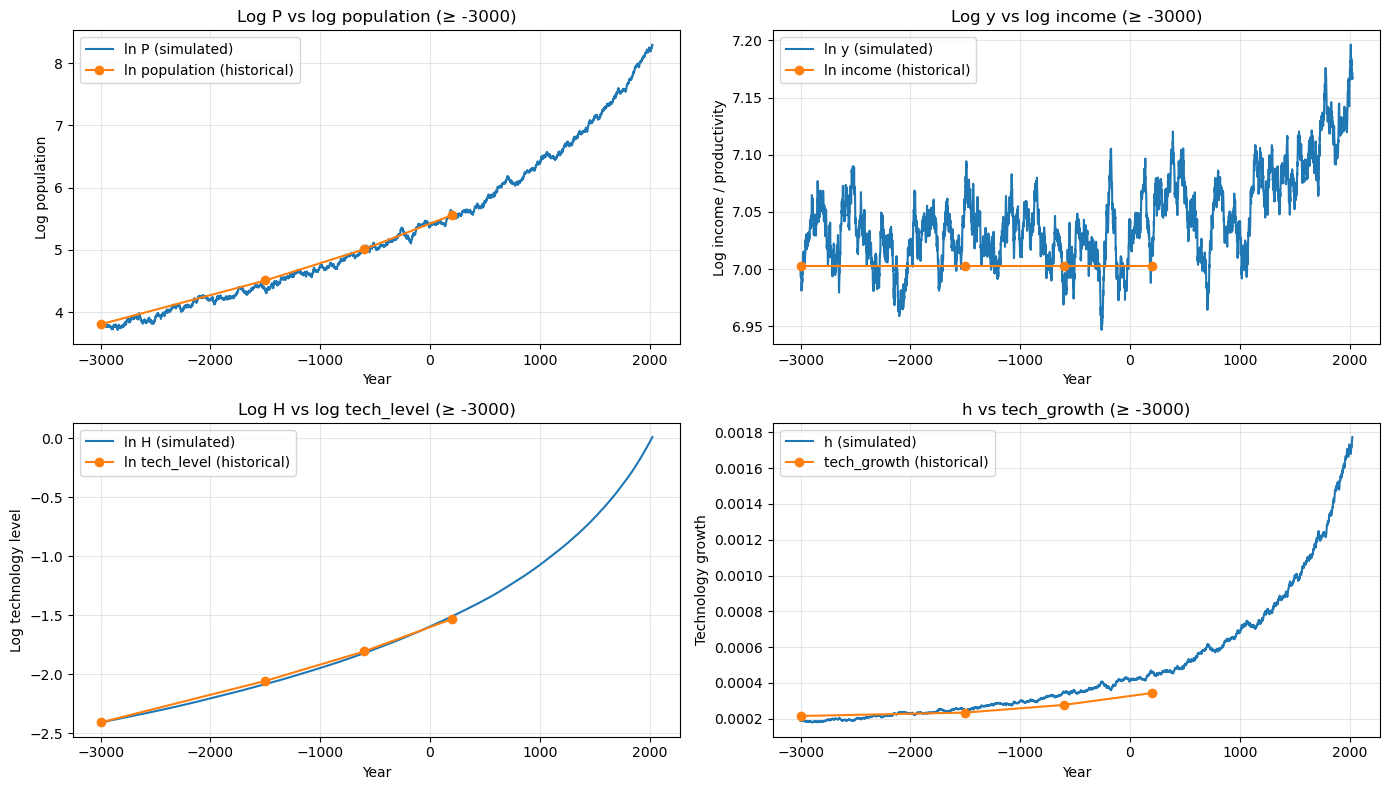

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Simulation series
year_arr = np.array(year)
P_arr    = np.array(P)
y_arr    = np.array(y)
H_arr    = np.array(H)
h_arr    = np.array(h)

# Historical data restricted to [-3000, 200]
df = human_history_df.copy()
df["year"] = df["year"].astype(int)
mask   = (df["year"] >= -3000) & (df["year"] <= 200)
df_sub = df.loc[mask].copy()

years_df = df_sub["year"].values
pop_df   = df_sub["population"].values
inc_df   = df_sub["income"].values
tech_df  = df_sub["tech_index"].values
gtech_df = df_sub["tech_growth"].values

# Log transforms for positive levels only
# (we drop or mask nonpositive values to avoid -inf)
def safe_log(x):
    x = np.array(x, dtype=float)
    x[x <= 0] = np.nan
    return np.log(x)

lnP_sim   = safe_log(P_arr)
lny_sim   = safe_log(y_arr)
lnH_sim   = safe_log(H_arr)

lnP_data  = safe_log(pop_df)
lny_data  = safe_log(inc_df)
lnH_data  = safe_log(tech_df)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# (1,1) log P and log population vs year
ax = axes[0, 0]
ax.plot(year_arr, lnP_sim, color="tab:blue", label="ln P (simulated)")
ax.plot(years_df, lnP_data, color="tab:orange", marker="o",
        linestyle="-", label="ln population (historical)")
ax.set_xlabel("Year")
ax.set_ylabel("Log population")
ax.set_title("Log P vs log population (≥ -3000)")
ax.grid(True, alpha=0.3)
ax.legend()

# (1,2) log y and log income vs year
ax = axes[0, 1]
ax.plot(year_arr, lny_sim, color="tab:blue", label="ln y (simulated)")
ax.plot(years_df, lny_data, color="tab:orange", marker="o",
        linestyle="-", label="ln income (historical)")
ax.set_xlabel("Year")
ax.set_ylabel("Log income / productivity")
ax.set_title("Log y vs log income (≥ -3000)")
ax.grid(True, alpha=0.3)
ax.legend()

# (2,1) log H and log tech_level vs year
ax = axes[1, 0]
ax.plot(year_arr, lnH_sim, color="tab:blue", label="ln H (simulated)")
ax.plot(years_df, lnH_data, color="tab:orange", marker="o",
        linestyle="-", label="ln tech_level (historical)")
ax.set_xlabel("Year")
ax.set_ylabel("Log technology level")
ax.set_title("Log H vs log tech_level (≥ -3000)")
ax.grid(True, alpha=0.3)
ax.legend()

# (2,2) h and tech_growth vs year (kept in levels: growth rates)
ax = axes[1, 1]
ax.plot(year_arr, h_arr, color="tab:blue", label="h (simulated)")
ax.plot(years_df, gtech_df, color="tab:orange", marker="o",
        linestyle="-", label="tech_growth (historical)")
ax.set_xlabel("Year")
ax.set_ylabel("Technology growth")
ax.set_title("h vs tech_growth (≥ -3000)")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()


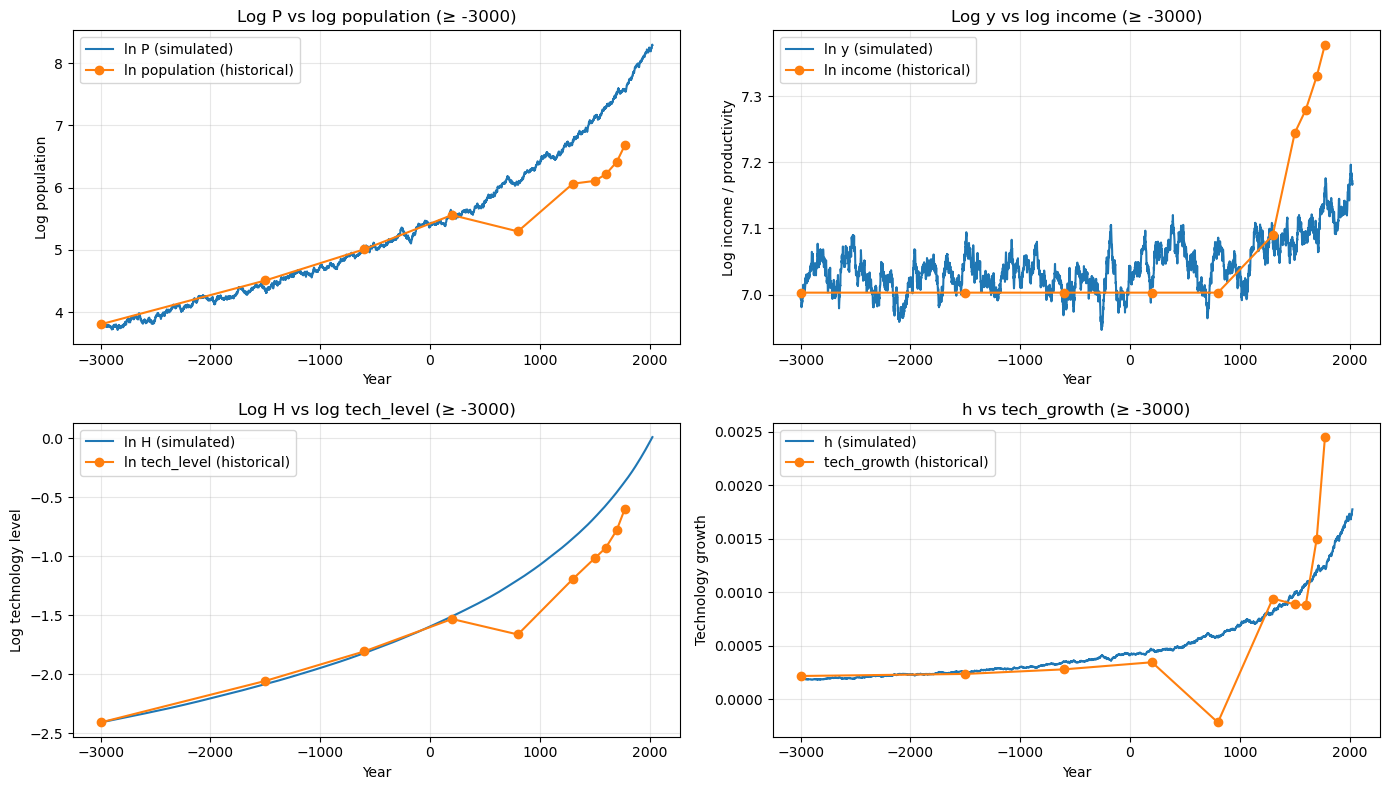

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Simulation series
year_arr = np.array(year)
P_arr    = np.array(P)
y_arr    = np.array(y)
H_arr    = np.array(H)
h_arr    = np.array(h)

# Historical data restricted to [-3000, 1775]
df = human_history_df.copy()
df["year"] = df["year"].astype(int)
mask   = (df["year"] >= -3000) & (df["year"] <= 1775)
df_sub = df.loc[mask].copy()

years_df = df_sub["year"].values
pop_df   = df_sub["population"].values
inc_df   = df_sub["income"].values
tech_df  = df_sub["tech_index"].values
gtech_df = df_sub["tech_growth"].values

# Log transforms for positive levels only
# (we drop or mask nonpositive values to avoid -inf)
def safe_log(x):
    x = np.array(x, dtype=float)
    x[x <= 0] = np.nan
    return np.log(x)

lnP_sim   = safe_log(P_arr)
lny_sim   = safe_log(y_arr)
lnH_sim   = safe_log(H_arr)

lnP_data  = safe_log(pop_df)
lny_data  = safe_log(inc_df)
lnH_data  = safe_log(tech_df)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# (1,1) log P and log population vs year
ax = axes[0, 0]
ax.plot(year_arr, lnP_sim, color="tab:blue", label="ln P (simulated)")
ax.plot(years_df, lnP_data, color="tab:orange", marker="o",
        linestyle="-", label="ln population (historical)")
ax.set_xlabel("Year")
ax.set_ylabel("Log population")
ax.set_title("Log P vs log population (≥ -3000)")
ax.grid(True, alpha=0.3)
ax.legend()

# (1,2) log y and log income vs year
ax = axes[0, 1]
ax.plot(year_arr, lny_sim, color="tab:blue", label="ln y (simulated)")
ax.plot(years_df, lny_data, color="tab:orange", marker="o",
        linestyle="-", label="ln income (historical)")
ax.set_xlabel("Year")
ax.set_ylabel("Log income / productivity")
ax.set_title("Log y vs log income (≥ -3000)")
ax.grid(True, alpha=0.3)
ax.legend()

# (2,1) log H and log tech_level vs year
ax = axes[1, 0]
ax.plot(year_arr, lnH_sim, color="tab:blue", label="ln H (simulated)")
ax.plot(years_df, lnH_data, color="tab:orange", marker="o",
        linestyle="-", label="ln tech_level (historical)")
ax.set_xlabel("Year")
ax.set_ylabel("Log technology level")
ax.set_title("Log H vs log tech_level (≥ -3000)")
ax.grid(True, alpha=0.3)
ax.legend()

# (2,2) h and tech_growth vs year (kept in levels: growth rates)
ax = axes[1, 1]
ax.plot(year_arr, h_arr, color="tab:blue", label="h (simulated)")
ax.plot(years_df, gtech_df, color="tab:orange", marker="o",
        linestyle="-", label="tech_growth (historical)")
ax.set_xlabel("Year")
ax.set_ylabel("Technology growth")
ax.set_title("h vs tech_growth (≥ -3000)")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()


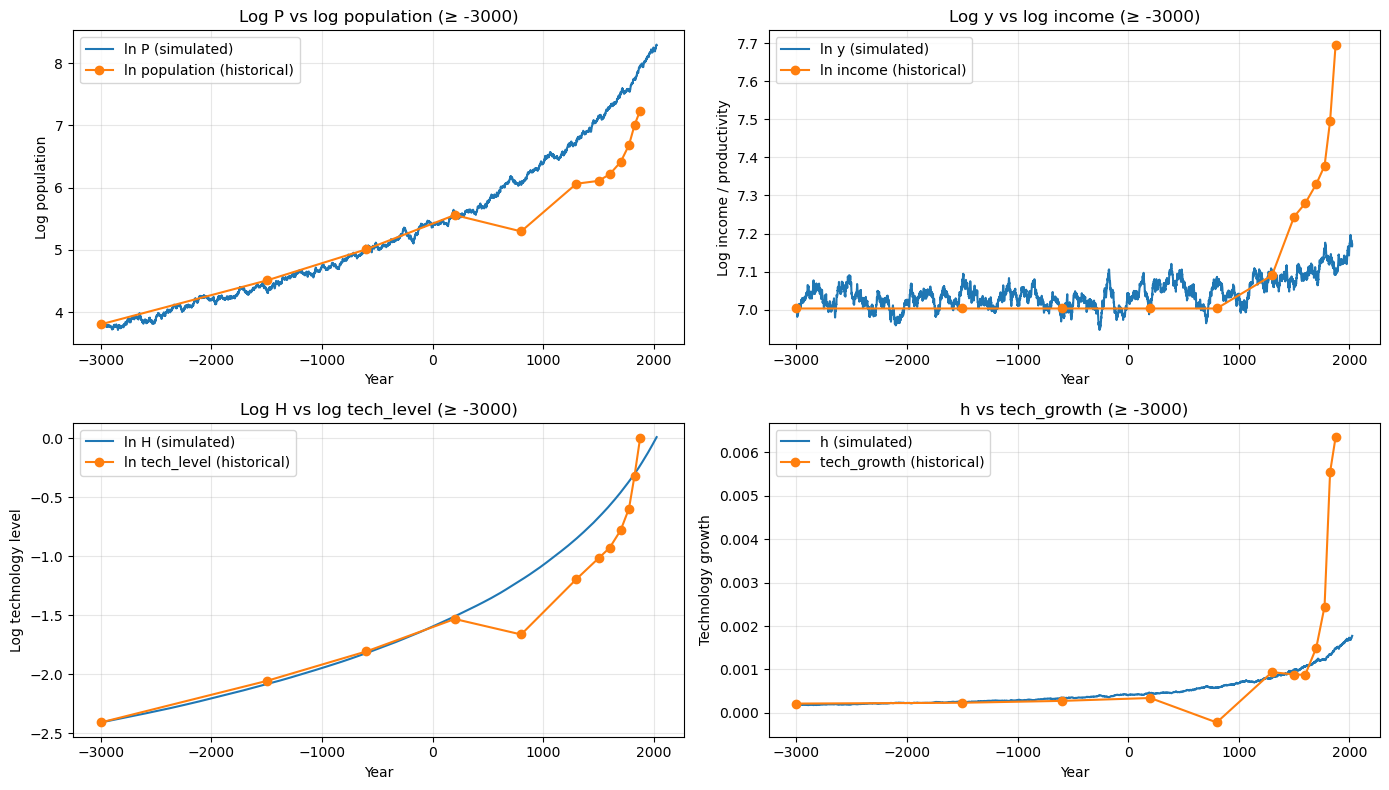

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Simulation series
year_arr = np.array(year)
P_arr    = np.array(P)
y_arr    = np.array(y)
H_arr    = np.array(H)
h_arr    = np.array(h)

# Historical data restricted to [-3000, 1875]
df = human_history_df.copy()
df["year"] = df["year"].astype(int)
mask   = (df["year"] >= -3000) & (df["year"] <= 1875)
df_sub = df.loc[mask].copy()

years_df = df_sub["year"].values
pop_df   = df_sub["population"].values
inc_df   = df_sub["income"].values
tech_df  = df_sub["tech_index"].values
gtech_df = df_sub["tech_growth"].values

# Log transforms for positive levels only
# (we drop or mask nonpositive values to avoid -inf)
def safe_log(x):
    x = np.array(x, dtype=float)
    x[x <= 0] = np.nan
    return np.log(x)

lnP_sim   = safe_log(P_arr)
lny_sim   = safe_log(y_arr)
lnH_sim   = safe_log(H_arr)

lnP_data  = safe_log(pop_df)
lny_data  = safe_log(inc_df)
lnH_data  = safe_log(tech_df)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# (1,1) log P and log population vs year
ax = axes[0, 0]
ax.plot(year_arr, lnP_sim, color="tab:blue", label="ln P (simulated)")
ax.plot(years_df, lnP_data, color="tab:orange", marker="o",
        linestyle="-", label="ln population (historical)")
ax.set_xlabel("Year")
ax.set_ylabel("Log population")
ax.set_title("Log P vs log population (≥ -3000)")
ax.grid(True, alpha=0.3)
ax.legend()

# (1,2) log y and log income vs year
ax = axes[0, 1]
ax.plot(year_arr, lny_sim, color="tab:blue", label="ln y (simulated)")
ax.plot(years_df, lny_data, color="tab:orange", marker="o",
        linestyle="-", label="ln income (historical)")
ax.set_xlabel("Year")
ax.set_ylabel("Log income / productivity")
ax.set_title("Log y vs log income (≥ -3000)")
ax.grid(True, alpha=0.3)
ax.legend()

# (2,1) log H and log tech_level vs year
ax = axes[1, 0]
ax.plot(year_arr, lnH_sim, color="tab:blue", label="ln H (simulated)")
ax.plot(years_df, lnH_data, color="tab:orange", marker="o",
        linestyle="-", label="ln tech_level (historical)")
ax.set_xlabel("Year")
ax.set_ylabel("Log technology level")
ax.set_title("Log H vs log tech_level (≥ -3000)")
ax.grid(True, alpha=0.3)
ax.legend()

# (2,2) h and tech_growth vs year (kept in levels: growth rates)
ax = axes[1, 1]
ax.plot(year_arr, h_arr, color="tab:blue", label="h (simulated)")
ax.plot(years_df, gtech_df, color="tab:orange", marker="o",
        linestyle="-", label="tech_growth (historical)")
ax.set_xlabel("Year")
ax.set_ylabel("Technology growth")
ax.set_title("h vs tech_growth (≥ -3000)")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()


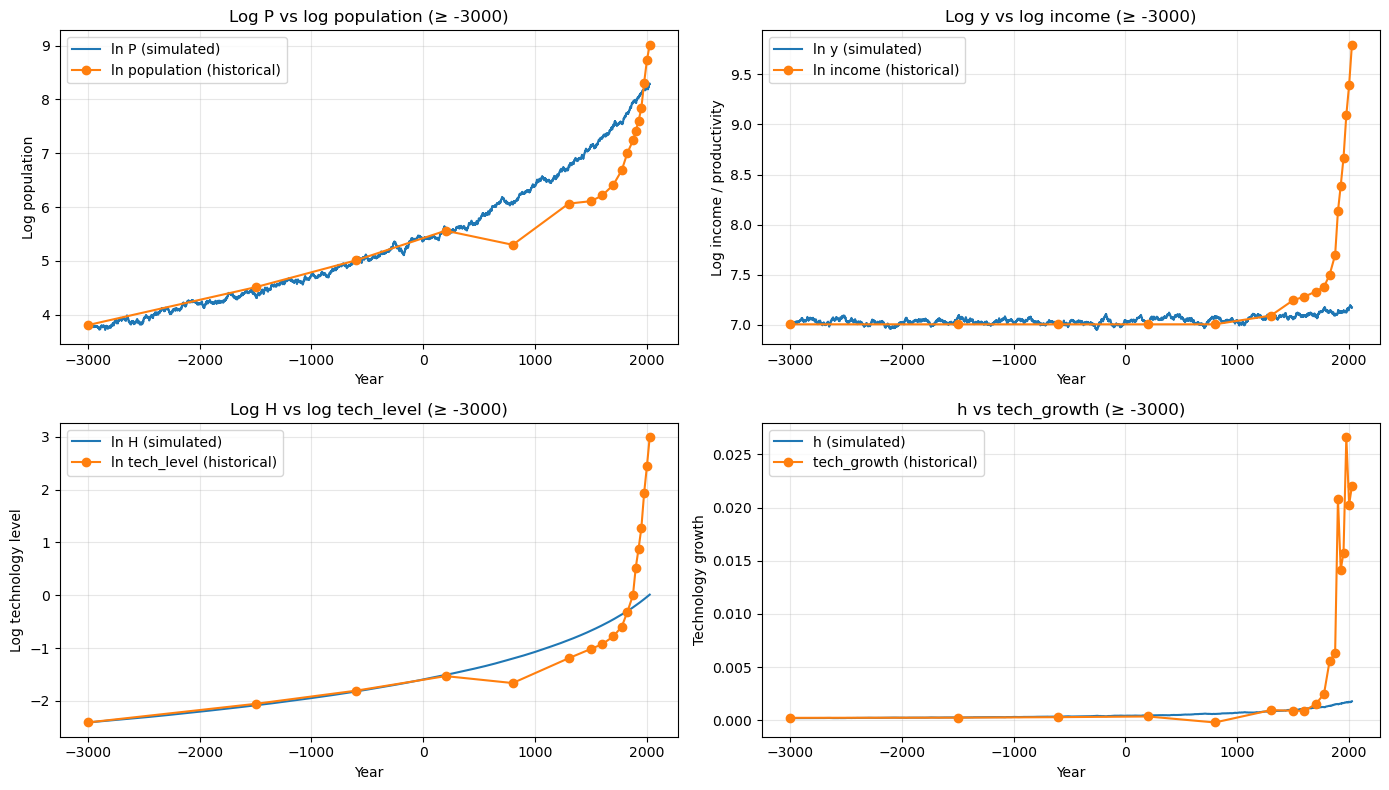

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Simulation series
year_arr = np.array(year)
P_arr    = np.array(P)
y_arr    = np.array(y)
H_arr    = np.array(H)
h_arr    = np.array(h)

# Historical data restricted to [-3000, 2025]
df = human_history_df.copy()
df["year"] = df["year"].astype(int)
mask   = (df["year"] >= -3000) & (df["year"] <= 2025)
df_sub = df.loc[mask].copy()

years_df = df_sub["year"].values
pop_df   = df_sub["population"].values
inc_df   = df_sub["income"].values
tech_df  = df_sub["tech_index"].values
gtech_df = df_sub["tech_growth"].values

# Log transforms for positive levels only
# (we drop or mask nonpositive values to avoid -inf)
def safe_log(x):
    x = np.array(x, dtype=float)
    x[x <= 0] = np.nan
    return np.log(x)

lnP_sim   = safe_log(P_arr)
lny_sim   = safe_log(y_arr)
lnH_sim   = safe_log(H_arr)

lnP_data  = safe_log(pop_df)
lny_data  = safe_log(inc_df)
lnH_data  = safe_log(tech_df)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# (1,1) log P and log population vs year
ax = axes[0, 0]
ax.plot(year_arr, lnP_sim, color="tab:blue", label="ln P (simulated)")
ax.plot(years_df, lnP_data, color="tab:orange", marker="o",
        linestyle="-", label="ln population (historical)")
ax.set_xlabel("Year")
ax.set_ylabel("Log population")
ax.set_title("Log P vs log population (≥ -3000)")
ax.grid(True, alpha=0.3)
ax.legend()

# (1,2) log y and log income vs year
ax = axes[0, 1]
ax.plot(year_arr, lny_sim, color="tab:blue", label="ln y (simulated)")
ax.plot(years_df, lny_data, color="tab:orange", marker="o",
        linestyle="-", label="ln income (historical)")
ax.set_xlabel("Year")
ax.set_ylabel("Log income / productivity")
ax.set_title("Log y vs log income (≥ -3000)")
ax.grid(True, alpha=0.3)
ax.legend()

# (2,1) log H and log tech_level vs year
ax = axes[1, 0]
ax.plot(year_arr, lnH_sim, color="tab:blue", label="ln H (simulated)")
ax.plot(years_df, lnH_data, color="tab:orange", marker="o",
        linestyle="-", label="ln tech_level (historical)")
ax.set_xlabel("Year")
ax.set_ylabel("Log technology level")
ax.set_title("Log H vs log tech_level (≥ -3000)")
ax.grid(True, alpha=0.3)
ax.legend()

# (2,2) h and tech_growth vs year (kept in levels: growth rates)
ax = axes[1, 1]
ax.plot(year_arr, h_arr, color="tab:blue", label="h (simulated)")
ax.plot(years_df, gtech_df, color="tab:orange", marker="o",
        linestyle="-", label="tech_growth (historical)")
ax.set_xlabel("Year")
ax.set_ylabel("Technology growth")
ax.set_title("h vs tech_growth (≥ -3000)")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()


In [9]:
# save
# later, in any notebook
# import pandas as pd
# human_history_df = pd.read_feather("human_history_df.feather")


human_history_df.to_feather("data/human_history_df.feather")

